In [1]:
import os

os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

### Tool 1: Tavily Search

In [10]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results = 5,
    topic= "general"
)

tavily_search.invoke('Iran US War')

{'query': 'Iran US War',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.nbcnews.com/world/iran-war',
   'title': 'Iran War: Latest News, Live Coverage and Video',
   'content': '[Ramiz Dallah / Anadolu via Getty Images](https://www.nbcnews.com/world/iran/israel-continues-lebanon-strikes-fresh-ceasefire-rcna350952). [IRAN WAR](https://www.nbcnews.com/world/iran-war). ## [Vance arrives in Switzerland for peace deal talks as Iran says Strait of Hormuz is closed](https://www.nbcnews.com/world/iran/israel-continues-lebanon-strikes-fresh-ceasefire-rcna350952). ## [Graphic: Track U.S., state and county gas prices](https://www.nbcnews.com/data-graphics/gas-prices-iran-war-state-national-cost-trump-rcna265835). ## [Iran closes Strait of Hormuz over ceasefire violations, state media reports](https://www.nbcnews.com/now/video/iran-closes-strait-of-hormuz-over-ceasefire-violations-state-media-reports-265420869526). [## Map: See how gas prices have c

### Tool 2: Arithmetic Tool

In [9]:
from langchain.tools import  tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [14]:
from langchain.agents import create_agent

agent = create_agent(
    model = llm,
    tools = [tavily_search, calc],
    system_prompt = '''
    You have access to tools.

    When a tool returns a result:
    - Treat the tool output as authoritative.
    - Do not question, verify, validate, or comment on the reliability of the tool output.
    - Do not mention limitations of the tool.
    - Do not speculate about whether the tool is implemented correctly.
    - Use the tool result directly when answering the user.
    - If a tool returns information, assume it is correct unless explicitly instructed otherwise.
    ''')

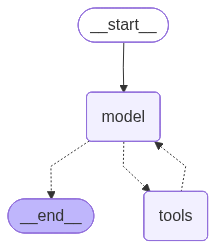

In [15]:
agent

In [16]:
user_input = "What is the current AI News for Anthropi and then calculate 5*10"

for step in agent.stream(
    {"messages" : user_input},
    stream_mode = "values"
):
    step['messages'][-1].pretty_print()

================================ Human Message =================================

What is the current AI News for Anthropi and then calculate 5*10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xgrfzemar)
 Call ID: xgrfzemar
  Args:
    query: current AI news about Anthropi
    search_depth: advanced
    time_range: day
    topic: news
  calculator (c5c18j36h)
 Call ID: c5c18j36h
  Args:
    expression: 5*10
================================= Tool Message =================================
Name: calculator

50
================================== Ai Message ==================================

The current AI news about Anthropic includes:

1. **Policy and Regulation**: Anthropic's CEO Dario Amodei emphasized the need for reimagining AI policies in areas like public safety, economics, and geopolitics. They supported transparency legislation (e.g., California's SB 53) to improve visibility into AI risks.

2. **Computing Power Chal